# K-Nearest Neighbors (KNN) — 2-Hour Hands-On Practical Session
### Classification with Iris • Regression with Linnerud

## 0. Import Libraries

In [1]:
# Core data handling
import numpy as np                                   # numerical arrays
import pandas as pd                                   # DataFrames

# Plotting
import matplotlib.pyplot as plt                        # base plotting
import seaborn as sns                                  # nicer statistical plots
sns.set_style("whitegrid")                              # clean plot background

# Built-in scikit-learn datasets
from sklearn.datasets import load_iris, load_linnerud   # classification & regression data

# Preprocessing & splitting
from sklearn.model_selection import train_test_split    # train/test split
from sklearn.preprocessing import StandardScaler        # feature scaling

# KNN models
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor

RANDOM_STATE = 42   # fixed seed used everywhere for reproducibility

print("Libraries imported successfully.")

Libraries imported successfully.


---
## Part 1 — KNN Classification (Iris Dataset)

The Iris dataset has 150 flower samples from 3 species, described by 4 measurements
(sepal length/width, petal length/width). Goal: predict the **species** from the
measurements.


### 1.1 Load the Dataset

In [2]:
# Load the built-in Iris dataset (bundled with scikit-learn, no internet needed)
iris = load_iris()

# iris.data -> feature values, iris.target -> encoded class labels (0,1,2)
# iris.feature_names -> column names, iris.target_names -> class name strings
print("Feature names:", iris.feature_names)
print("Target (class) names:", iris.target_names)
print("Data shape:", iris.data.shape)
print("Target shape:", iris.target.shape)

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target (class) names: ['setosa' 'versicolor' 'virginica']
Data shape: (150, 4)
Target shape: (150,)


In [3]:
# Combine features + target into a single, easy-to-explore DataFrame
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Add the target as a readable species name column (not just 0/1/2)
iris_df["species"] = pd.Categorical.from_codes(iris.target, iris.target_names)

iris_df.head()   # preview the first 5 rows

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### 1.2 Explore the Dataset

In [4]:
# Basic structural info
print(iris_df.shape)          # (rows, columns)
iris_df.info()                 # column dtypes + non-null counts

(150, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   sepal length (cm)  150 non-null    float64 
 1   sepal width (cm)   150 non-null    float64 
 2   petal length (cm)  150 non-null    float64 
 3   petal width (cm)   150 non-null    float64 
 4   species            150 non-null    category
dtypes: category(1), float64(4)
memory usage: 5.1 KB


In [5]:
# Summary statistics for each numeric feature
iris_df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [6]:
# How many samples per species? (checking class balance)
iris_df["species"].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

### 1.3 Visualize the Dataset

C:\Users\DELL\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\DELL\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1057: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = data.groupby(
C:\Users\DELL\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\DELL\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1057: FutureWarning: The default of observed=False is deprecated and will

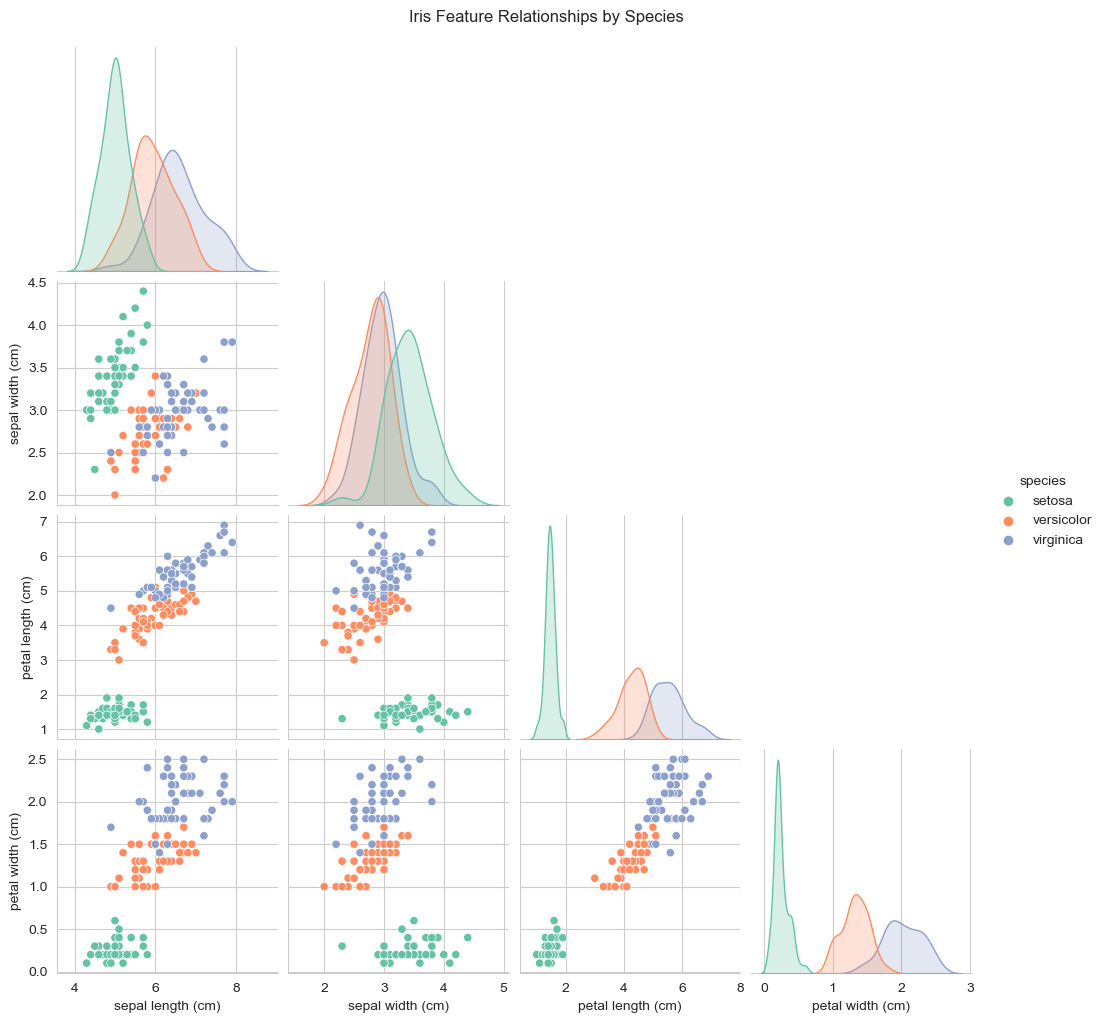

In [7]:
# Pairplot: scatter plot of every feature pair, colored by species
sns.pairplot(iris_df, hue="species", palette="Set2", corner=True)
plt.suptitle("Iris Feature Relationships by Species", y=1.02)
plt.show()

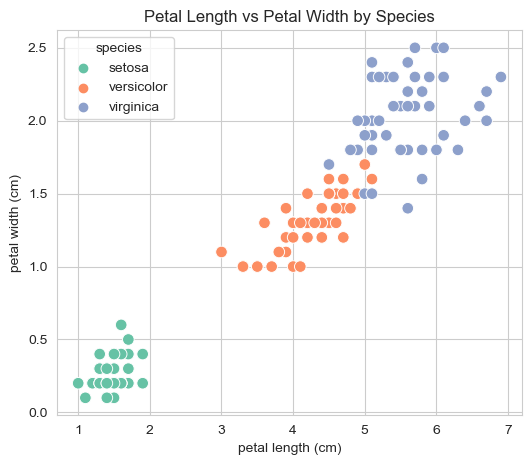

In [8]:
# Focus on the two most separable features: petal length & petal width
plt.figure(figsize=(6, 5))
sns.scatterplot(
    data=iris_df, x="petal length (cm)", y="petal width (cm)",
    hue="species", palette="Set2", s=70
)
plt.title("Petal Length vs Petal Width by Species")
plt.show()

### 1.4 Train-Test Split

In [9]:
# Separate features (X) and target (y)
X_iris = iris.data
y_iris = iris.target

# Split into training (80%) and testing (20%) sets
# stratify=y_iris keeps the same class proportions in both splits
X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=RANDOM_STATE, stratify=y_iris
)

print("Training samples:", X_train_iris.shape[0])
print("Testing samples:", X_test_iris.shape[0])

Training samples: 120
Testing samples: 30


### 1.5 Feature Scaling

KNN relies on **distance calculations**, so features must be on the same scale — otherwise
a feature with a larger numeric range would dominate the distance.


In [10]:
# Create and fit the scaler ONLY on training data, then apply to both sets
scaler_iris = StandardScaler()
X_train_iris_scaled = scaler_iris.fit_transform(X_train_iris)   # fit + transform on train
X_test_iris_scaled = scaler_iris.transform(X_test_iris)          # transform only on test

print("Scaled training data — mean per feature (should be ~0):", np.round(X_train_iris_scaled.mean(axis=0), 2))
print("Scaled training data — std per feature (should be ~1): ", np.round(X_train_iris_scaled.std(axis=0), 2))

Scaled training data — mean per feature (should be ~0): [-0. -0.  0.  0.]
Scaled training data — std per feature (should be ~1):  [1. 1. 1. 1.]


### 1.6 Train a KNN Classifier (K = 5)

In [11]:
# Create a KNN classifier with 5 neighbors
knn_clf = KNeighborsClassifier(n_neighbors=5)

# "Fit" simply stores the training data (KNN is a lazy learner — no real training)
knn_clf.fit(X_train_iris_scaled, y_train_iris)

print("KNN classifier (K=5) is ready.")

KNN classifier (K=5) is ready.


### 1.7 Make Predictions

In [12]:
# Predict species for the test set
y_pred_iris = knn_clf.predict(X_test_iris_scaled)

# Compare actual vs predicted species names side-by-side
comparison_df = pd.DataFrame({
    "Actual": iris.target_names[y_test_iris],
    "Predicted": iris.target_names[y_pred_iris]
})
comparison_df

,Actual,Predicted
0,setosa,setosa
1,virginica,virginica
2,versicolor,versicolor
3,versicolor,versicolor
4,setosa,setosa
5,versicolor,versicolor
6,setosa,setosa
7,setosa,setosa
8,virginica,virginica
9,versicolor,versicolor


In [13]:
# predict_proba gives the model's confidence for each class
proba_iris = knn_clf.predict_proba(X_test_iris_scaled)

proba_df = pd.DataFrame(proba_iris, columns=iris.target_names)
proba_df.head()

,setosa,versicolor,virginica
0,1.0,0.0,0.0
1,0.0,0.4,0.6
2,0.0,1.0,0.0
3,0.0,1.0,0.0
4,1.0,0.0,0.0


### 1.8 Predict a Brand-New Flower

In [14]:
# A new, unseen flower measurement: sepal length, sepal width, petal length, petal width
new_flower = np.array([[5.8, 3.0, 4.2, 1.3]])

# Scale it using the SAME scaler fitted on training data
new_flower_scaled = scaler_iris.transform(new_flower)

# Predict its species
predicted_species = knn_clf.predict(new_flower_scaled)
print("Predicted species:", iris.target_names[predicted_species][0])

Predicted species: versicolor


### 1.9 Trying Different K Values

Let's train several KNN classifiers with different `K` and compare how their predictions
change for the same test samples.


In [15]:
# List of K values to try
k_values = [1, 3, 5, 7, 9, 15, 25]

# Store predictions from each K in a dictionary
predictions_by_k = {}

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)             # create model with this K
    model.fit(X_train_iris_scaled, y_train_iris)              # fit on training data
    preds = model.predict(X_test_iris_scaled)                 # predict on test data
    predictions_by_k[f"K={k}"] = iris.target_names[preds]     # store readable predictions

# Build a comparison table: rows = test samples, columns = predictions for each K
k_comparison_df = pd.DataFrame(predictions_by_k)
k_comparison_df.insert(0, "Actual", iris.target_names[y_test_iris])
k_comparison_df

,Actual,K=1,K=3,K=5,K=7,K=9,K=15,K=25
0,setosa,setosa,setosa,setosa,setosa,setosa,setosa,setosa
1,virginica,virginica,virginica,virginica,virginica,virginica,virginica,virginica
2,versicolor,versicolor,versicolor,versicolor,versicolor,versicolor,versicolor,versicolor
3,versicolor,versicolor,versicolor,versicolor,versicolor,versicolor,versicolor,versicolor
4,setosa,setosa,setosa,setosa,setosa,setosa,setosa,setosa
5,versicolor,versicolor,versicolor,versicolor,versicolor,versicolor,versicolor,versicolor
6,setosa,setosa,setosa,setosa,setosa,setosa,setosa,setosa
7,setosa,setosa,setosa,setosa,setosa,setosa,setosa,setosa
8,virginica,virginica,virginica,virginica,virginica,virginica,virginica,virginica
9,versicolor,versicolor,versicolor,versicolor,versicolor,versicolor,versicolor,versicolor


### 1.10 Visualize Decision Boundaries for Different K

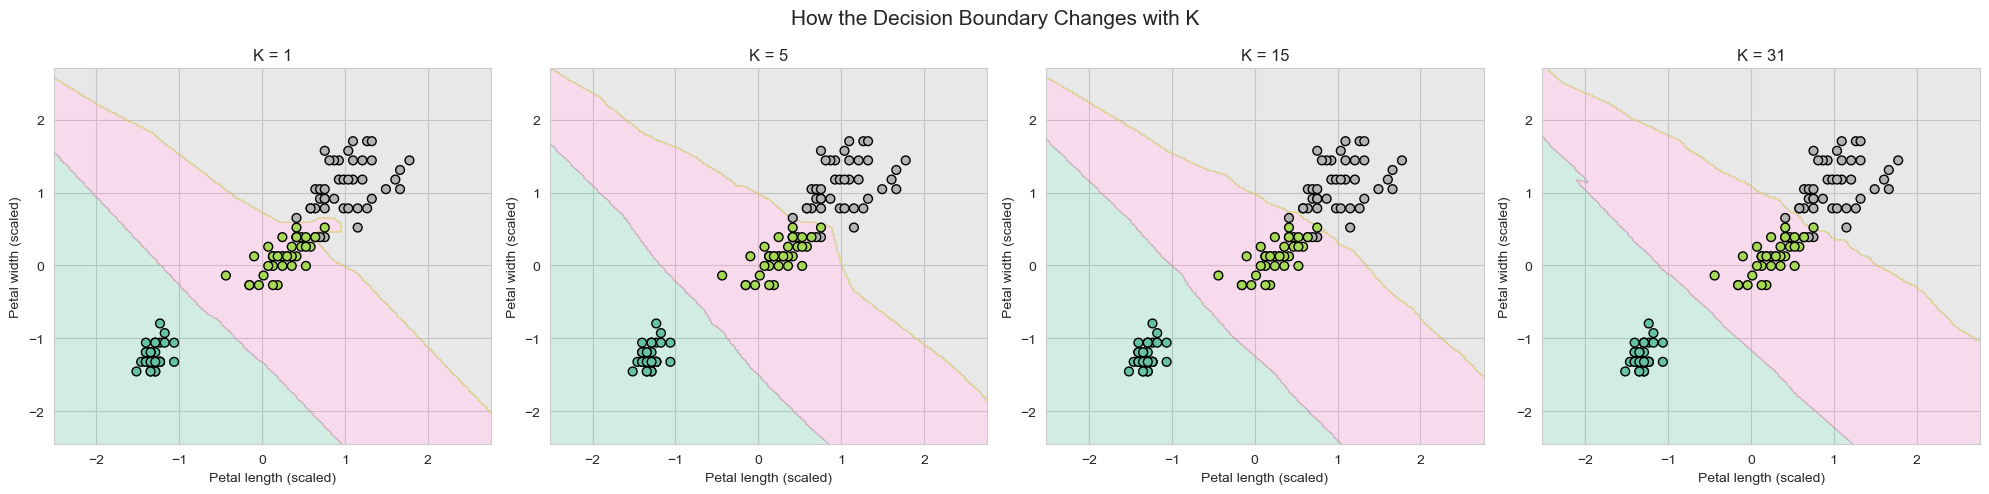

In [16]:
# To visualize a 2D decision boundary, we use just 2 features: petal length & petal width
X_vis = iris.data[:, 2:4]          # petal length, petal width columns only
y_vis = iris.target

# Split and scale (same process as before, but only 2 features)
X_train_vis, X_test_vis, y_train_vis, y_test_vis = train_test_split(
    X_vis, y_vis, test_size=0.2, random_state=RANDOM_STATE, stratify=y_vis
)
scaler_vis = StandardScaler()
X_train_vis_scaled = scaler_vis.fit_transform(X_train_vis)

# Create a mesh grid covering the feature space, used to color the background by predicted class
x_min, x_max = X_train_vis_scaled[:, 0].min() - 1, X_train_vis_scaled[:, 0].max() + 1
y_min, y_max = X_train_vis_scaled[:, 1].min() - 1, X_train_vis_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
boundary_k_values = [1, 5, 15, 31]

for ax, k in zip(axes, boundary_k_values):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_vis_scaled, y_train_vis)

    # Predict the class for every point on the mesh grid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Draw the decision regions and overlay the actual training points
    ax.contourf(xx, yy, Z, alpha=0.3, cmap="Set2")
    ax.scatter(X_train_vis_scaled[:, 0], X_train_vis_scaled[:, 1],
               c=y_train_vis, cmap="Set2", edgecolor="black", s=40)
    ax.set_title(f"K = {k}")
    ax.set_xlabel("Petal length (scaled)")
    ax.set_ylabel("Petal width (scaled)")

plt.suptitle("How the Decision Boundary Changes with K", fontsize=15)
plt.tight_layout()
plt.show()

**Observation:** Small `K` (like 1) creates a jagged, complex boundary that closely
follows individual points. Large `K` (like 31) creates a much smoother, simpler boundary.
We'll discuss this trade-off in Section 5.


---
## 6. Practice Exercises (Try During the Session)

1. Load the Iris dataset and print how many samples belong to each species using
   `value_counts()`.
2. Create a scatter plot of `sepal length` vs `sepal width`, colored by species.
3. Split the Iris data into 70% train / 30% test instead of 80/20.
4. Train a `KNeighborsClassifier` with `K=9` and predict the species of the first 5 test
   samples.
5. Using the Linnerud dataset, create a scatter plot of `Jumps` vs `Pulse`.
6. Train a `KNeighborsRegressor` with `K=2` to predict `Waist` (instead of `Weight`) from
   the exercise features.
7. For a new athlete with `Chins=10, Situps=150, Jumps=60`, predict their `Weight` using
   your trained KNN regressor.


## 7. Coding Assignments (More Involved)

**Assignment 1 — Manual Nearest Neighbor**
Without using `KNeighborsClassifier`, write your own function `find_k_nearest(point, X_train, y_train, k)`
that:
- Computes the Euclidean distance from `point` to every row in `X_train`
- Returns the labels of the `k` closest training points
(Hint: use `np.linalg.norm` for distance calculation.)

**Assignment 2 — K Sweep Table**
Write a loop that trains a `KNeighborsClassifier` for every `K` from 1 to 20 on the Iris
training data, and store each model's **predictions on a single fixed test sample** in a
list. Print how many different predicted classes appear across all K values for that one
sample.

**Assignment 3 — Weighted KNN**
Retrain the Iris classifier using `KNeighborsClassifier(n_neighbors=5, weights="distance")`
instead of the default `weights="uniform"`. Compare the predicted probabilities
(`predict_proba`) with the uniform-weight version for the same test sample.

**Assignment 4 — Multi-Target Regression**
The Linnerud dataset actually has **3 targets** (`Weight`, `Waist`, `Pulse`) at once.
Train a single `KNeighborsRegressor` on `y = linnerud.target` (all 3 columns together,
instead of just `Weight`) and predict all three physiological values for a new exercise
measurement `[Chins=8, Situps=140, Jumps=50]`.

**Assignment 5 — Custom Distance Metric**
Retrain a KNN classifier on Iris using `metric="manhattan"` instead of the default
Euclidean distance. Compare predictions on the test set with the Euclidean version.
